In [1]:
# Cell 1 — Imports
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
from pathlib import Path
import faiss

from rdkit import Chem
from rdkit.Chem import QED, Descriptors

ROOT = Path("..")
DATA = ROOT / "data"
EMB = ROOT / "embeddings"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)


Using: cpu


In [2]:
# Cell 2 — Load FAISS Index
pubchem_index = faiss.read_index(str(EMB / "pubchem_index.faiss"))
pubchem_meta = pd.read_parquet(EMB / "pubchem_metadata.parquet")

print("PubChem vectors:", pubchem_index.ntotal)


PubChem vectors: 192783


In [3]:
# Cell 3 — Build SMILES vocabulary
smiles_list = pubchem_meta["SMILES"].dropna().tolist()

chars = sorted(list(set("".join(smiles_list))))
chars.append("!")  # EOS token for sequence stopping

char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}

vocab_size = len(chars)
print("Vocabulary size:", vocab_size)


Vocabulary size: 68


In [4]:
# Cell 4 — Transformer SMILES Generator

class SmilesTransformer(nn.Module):
    def __init__(self, vocab_size, emb=128, nhead=4, layers=4, dim_feedforward=256):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, emb)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=layers)
        self.fc = nn.Linear(emb, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        out = self.transformer(x)
        out = self.fc(out)
        return out

model = SmilesTransformer(vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0008)
criterion = nn.CrossEntropyLoss()


In [5]:
# Cell 5 — Training transformer on SMILES

def tensorize(smile):
    return torch.tensor([char2idx[c] for c in smile], dtype=torch.long)

train_data = [s + "!" for s in smiles_list[:5000]]  # 5000 SMILES = fast & enough
# train_data = [s + "!" for s in smiles_list[:20000]]  # increased from 5000 → 20000


def train_epoch():
    model.train()
    total = 0

    for s in train_data:
        inp = tensorize(s[:-1]).unsqueeze(0).to(device)
        tgt = tensorize(s[1:]).to(device)

        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out.reshape(-1, vocab_size), tgt)
        loss.backward()
        optimizer.step()
        total += loss.item()

    return total / len(train_data)

for epoch in range(5):
    loss = train_epoch()
    print(f"Epoch {epoch+1}, Loss = {loss:.4f}")


Epoch 1, Loss = 1.4527
Epoch 2, Loss = 1.3916
Epoch 3, Loss = 1.3527
Epoch 4, Loss = 1.3274
Epoch 5, Loss = 1.3215


In [29]:
# Cell 6 — Transformer sampling

def sample_next_token(logits, temperature=0.8, top_k=25):
    logits = logits / temperature
    values, indices = torch.topk(logits, k=top_k)
    probs = torch.softmax(values, dim=-1)
    choice = torch.multinomial(probs, 1).item()
    return indices[choice].item()

def clean_smiles(s):
    allowed = set(chars)
    s = "".join([c for c in s if c in allowed])

    # Balance parentheses
    while s.count("(") > s.count(")"):
        s += ")"
    while s.count(")") > s.count("("):
        s = s.replace(")", "", 1)

    return s

def generate_transformer(seed="C", max_len=80):
    model.eval()

    tokens = [char2idx[c] for c in seed]
    inp = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_len):
        logits = model(inp)[0, -1]
        next_id = sample_next_token(logits)

        char = idx2char[next_id]
        if char == "!":
            break

        tokens.append(next_id)
        inp = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    return clean_smiles("".join(idx2char[t] for t in tokens))


In [30]:
# Cell 7 — RDKit validation

def validate(smiles_list):
    rows = []
    for sm in smiles_list:
        mol = Chem.MolFromSmiles(sm)

        if mol:
            rows.append({
                "SMILES": sm,
                "valid": True,
                "MolWt": Descriptors.MolWt(mol),
                "QED": QED.qed(mol),
                "LogP": Descriptors.MolLogP(mol)
            })
        else:
            rows.append({
                "SMILES": sm,
                "valid": False,
                "MolWt": None,
                "QED": None,
                "LogP": None
            })
    return pd.DataFrame(rows)


In [31]:
# Cell 8 — Retrieval using SMILES embedding model

from transformers import AutoTokenizer, AutoModel

smiles_tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")
smiles_model = AutoModel.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k").to(device)
smiles_model.eval()

def embed_query_smiles(s):
    enc = smiles_tokenizer([s], return_tensors="pt").to(device)
    with torch.no_grad():
        out = smiles_model(**enc)
    return out.last_hidden_state.mean(dim=1).cpu().numpy().astype("float32")

def retrieve_similar_smiles(query="CCO", k=5):
    qvec = embed_query_smiles(query)
    D, I = pubchem_index.search(qvec, k)
    df = pubchem_meta.iloc[I[0]].copy()
    df["distance"] = D[0]
    return df


In [32]:
# Cell 9 — Generation pipeline

def pipeline_generate_for_target(target, k_retrieve=3, num_generate=50):
    retrieved = retrieve_similar_smiles("CCO", k=k_retrieve)
    examples = retrieved["SMILES"].tolist()

    generated = [
        generate_transformer(seed=random.choice(examples)[:5])
        for _ in range(num_generate)
    ]
    

    val = validate(generated)
    val["target_query"] = target
    val["retrieved_examples"] = "|".join(examples)
    return val

targets = [
    "EGFR inhibitor",
    "Serotonin receptor antagonist",
    "Cyclooxygenase-2 inhibitor"
]

df_all = pd.concat([
    pipeline_generate_for_target(t)
    for t in targets
]).reset_index(drop=True)

df_all


[04:07:44] Explicit valence for atom # 3 O, 3, is greater than permitted
[04:07:44] SMILES Parse Error: ring closure 1 duplicates bond between atom 15 and atom 16 for input: 'COC1=OCOCOCOCC1OCOC1C1C1O1CO1C1=OC1CC1CCNC1'
[04:07:44] SMILES Parse Error: unclosed ring for input: 'COC1=CC=C=CC=C=OC=C1=C1=C=CC=C=CC=CCC1C1=C=C=C=C=C=CCCC=C=CCCC=OCC=CC1=C=C=C=C1=C=CCC'
[04:07:44] SMILES Parse Error: ring closure 1 duplicates bond between atom 2 and atom 3 for input: 'COC1=C1=C=COC=C=C=C1'
[04:07:44] Explicit valence for atom # 3 O, 3, is greater than permitted
[04:07:44] SMILES Parse Error: unclosed ring for input: 'C1=CCC=CC1=C=C=C=C=C1'
[04:07:44] SMILES Parse Error: ring closure 1 duplicates bond between atom 7 and atom 8 for input: 'COC1=CC1=COC1C1=C1C1=C1CCC1CCCC1CCC1C1CC1CC1C1'
[04:07:44] SMILES Parse Error: ring closure 1 duplicates bond between atom 2 and atom 3 for input: 'COC1=C1C=C1=CNCCCC=CC=C1C=C1=C1CCCCCCCCC=CCCCCCC=N'
[04:07:44] SMILES Parse Error: ring closure 1 duplicates bond

,SMILES,valid,MolWt,QED,LogP,target_query,retrieved_examples
0,C1=CCCC1CC,True,96.173,0.439471,2.3626,EGFR inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
1,COC1=CCCCCC1CCCO,True,184.279,0.726988,2.4794,EGFR inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
2,C1=CC=C=C=C=CC=CCC=CCC=C1,True,194.277,0.403254,4.0265,EGFR inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
3,CCOCCCCCCCCCCCCCCCCCCCCCCCCCC,True,410.771,0.128786,10.4052,EGFR inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
4,COC1=CC1,True,70.091,0.445451,0.9204,EGFR inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
...,...,...,...,...,...,...,...
145,COC1=OCCOC1=OOCCCN1=O=OC1CN1CC1=C[NC1=CC1CC1C1...,False,NaN,NaN,NaN,Cyclooxygenase-2 inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
146,COC1=C1]CCC1,False,NaN,NaN,NaN,Cyclooxygenase-2 inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
147,CCOCOCCCOCOCCCOOCCOCCOCCOCOCOCCOCOCCOCCOCOCOCO...,False,NaN,NaN,NaN,Cyclooxygenase-2 inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
148,COC1=O1=C1,False,NaN,NaN,NaN,Cyclooxygenase-2 inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...


In [33]:
OUT = DATA / "generated_molecules_transformer.csv"
df_all.to_csv(OUT, index=False)
print("Saved:", OUT)


Saved: ..\data\generated_molecules_transformer.csv


In [34]:
df_all.valid.mean()


0.5066666666666667

In [1]:
# Cell 1 — Imports
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import QED, Descriptors
import faiss
import random

ROOT = Path("..")
DATA = ROOT / "data"
EMB = ROOT / "embeddings"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)


Using: cpu


In [2]:
# Cell 2 — Load PubChem index + metadata

pubchem_index = faiss.read_index(str(EMB / "pubchem_index.faiss"))
pubchem_meta  = pd.read_parquet(EMB / "pubchem_metadata.parquet")

print("PubChem vectors:", pubchem_index.ntotal)
print("Metadata rows:", len(pubchem_meta))


PubChem vectors: 192783
Metadata rows: 196185


In [3]:
# Cell 3 — Build vocabulary
smiles_list = pubchem_meta["SMILES"].dropna().tolist()

chars = sorted(list(set("".join(smiles_list))))
chars.append("!")   # EOS token

stoi = {c:i for i,c in enumerate(chars)}
itos = {i:c for c,i in stoi.items()}

vocab_size = len(chars)
print("Vocab size =", vocab_size)


Vocab size = 68


In [4]:
# Cell 4 — GRU model

class SmilesGRU(nn.Module):
    def __init__(self, vocab_size, hidden=256, layers=3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 128)
        self.gru = nn.GRU(128, hidden, layers, batch_first=True)
        self.fc = nn.Linear(hidden, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.gru(x, hidden)
        out = self.fc(out)
        return out, hidden

model = SmilesGRU(vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss()


In [5]:
# Cell 5 — Training data
def tensorize(s):
    return torch.tensor([stoi[c] for c in s], dtype=torch.long)

train_data = [s + "!" for s in smiles_list[:5000]]  # limit for speed

def train_epoch():
    model.train()
    total_loss = 0

    for s in train_data:
        inp = tensorize(s[:-1]).unsqueeze(0).to(device)
        tgt = tensorize(s[1:]).to(device)

        optimizer.zero_grad()
        out, _ = model(inp)
        loss = criterion(out.reshape(-1, vocab_size), tgt)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_data)

for epoch in range(3):   # 3 epochs is enough
    loss = train_epoch()
    print(f"Epoch {epoch+1} Loss = {loss:.4f}")


Epoch 1 Loss = 1.2664
Epoch 2 Loss = 1.1382
Epoch 3 Loss = 1.1356


In [6]:
# Cell 6 — Improved sampling

def sample_next_token(logits, temperature=0.8, top_k=20):
    logits = logits / temperature
    values, indices = torch.topk(logits, k=top_k)
    probs = torch.softmax(values, dim=-1)
    next_idx = torch.multinomial(probs, 1)
    return indices[next_idx]

def clean_generated(sm):
    allowed = set(stoi.keys())
    sm = "".join([c for c in sm if c in allowed])

    # Fix parentheses imbalance
    while sm.count("(") > sm.count(")"):
        sm += ")"
    while sm.count(")") > sm.count("("):
        sm = sm.replace(")", "", 1)

    return sm

def generate_smiles_gru(seed="C", max_len=80):
    model.eval()

    seq = seed
    idxs = [stoi[c] for c in seed if c in stoi]

    x = torch.tensor([idxs], dtype=torch.long).to(device)
    hidden = None

    for _ in range(max_len):
        logits, hidden = model(x, hidden)
        logits = logits[0, -1]

        token = sample_next_token(logits)
        ch = itos[int(token)]

        if ch == "!":
            break

        seq += ch
        x = torch.tensor([[int(token)]], dtype=torch.long).to(device)

    return clean_generated(seq)


In [7]:
# Cell 7 — Validate generated molecules

def validate(smiles_list):
    rows = []
    for sm in smiles_list:
        mol = Chem.MolFromSmiles(sm)
        if mol:
            rows.append({
                "SMILES": sm,
                "valid": True,
                "MolWt": Descriptors.MolWt(mol),
                "QED": QED.qed(mol),
                "LogP": Descriptors.MolLogP(mol),
            })
        else:
            rows.append({
                "SMILES": sm,
                "valid": False,
                "MolWt": None,
                "QED": None,
                "LogP": None,
            })
    return pd.DataFrame(rows)


In [8]:
# Cell 8 — Retrieve seeds from PubChem

def get_seed_examples(k=5):
    rows = pubchem_meta.sample(n=k)
    return rows["SMILES"].tolist()


In [9]:
# Cell 9 — Pipeline

def pipeline_generate_for_target(target, k_retrieve=3, num_generate=5):

    examples = get_seed_examples(k_retrieve)

    generated = [
        generate_smiles_gru(seed=random.choice(examples)[:5])
        for _ in range(num_generate)
    ]

    val = validate(generated)
    val["target_query"] = target
    val["retrieved_examples"] = "|".join(examples)

    return val

targets = [
    "EGFR inhibitor",
    "Serotonin receptor antagonist",
    "Cyclooxygenase-2 inhibitor"
]

df_all = pd.concat([pipeline_generate_for_target(t) for t in targets]).reset_index(drop=True)
df_all


[19:55:47] SMILES Parse Error: unclosed ring for input: 'CC(C)CC(=O)C(=O)C1=CC=C(C=C1)CC3=CC=C(C=C2)C3=CC=CC=C3'
[19:55:47] SMILES Parse Error: unclosed ring for input: 'CC(CC1)N'
[19:55:47] SMILES Parse Error: unclosed ring for input: 'CCC1=CC=C(C=C1OC=C(C=CC2=CC=C3)C3=CC=CC(=C3C=C4)N)'
[19:55:47] SMILES Parse Error: unclosed ring for input: 'B1(C2=CC=CC=C3)'
[19:55:47] SMILES Parse Error: unclosed ring for input: 'B1(C2=CC=CC=C2)C(=O)C3=CC=CC=C3'
[19:55:47] SMILES Parse Error: unclosed ring for input: 'C1=CC=CC=C1C=CN(CCCCCC=CNCCC=CC3=C=CC=C3C2=CC=CC=C2)C3=CC=CC=C3C2=CC=CC=C32'
[19:55:47] SMILES Parse Error: unclosed ring for input: 'CC(=O)N(CCCN(CC(=O)N1))'
[19:55:47] SMILES Parse Error: extra close parentheses while parsing: CC(=OCC(=O)N)C)C(=O
[19:55:47] SMILES Parse Error: Failed parsing SMILES 'CC(=OCC(=O)N)C)C(=O' for input: 'CC(=OCC(=O)N)C)C(=O'
[19:55:47] SMILES Parse Error: unclosed ring for input: 'COC1=CC=C(C=C1)CCC2=NC3=CC=CC=C2'


,SMILES,valid,MolWt,QED,LogP,target_query,retrieved_examples
0,CC(C)CC1=CC=C=C(C=C1)CCCC2=C(C2)C3=CC=CC=C3,True,302.461,0.495272,6.6380,EGFR inhibitor,CCC1=C2COC(=O)C2=C(S1)C3=CC=CC=C3.CCC1=C2COC(=...
1,CC(C)CC(=O)C(=O)C1=CC=C(C=C1)CC3=CC=C(C=C2)C3=...,False,NaN,NaN,NaN,EGFR inhibitor,CCC1=C2COC(=O)C2=C(S1)C3=CC=CC=C3.CCC1=C2COC(=...
2,COC(=O)C,True,74.079,0.382967,0.1793,EGFR inhibitor,CCC1=C2COC(=O)C2=C(S1)C3=CC=CC=C3.CCC1=C2COC(=...
3,CC(CC1)N,False,NaN,NaN,NaN,EGFR inhibitor,CCC1=C2COC(=O)C2=C(S1)C3=CC=CC=C3.CCC1=C2COC(=...
4,CCC1=CC=C(C=C1OC=C(C=CC2=CC=C3)C3=CC=CC(=C3C=C...,False,NaN,NaN,NaN,EGFR inhibitor,CCC1=C2COC(=O)C2=C(S1)C3=CC=CC=C3.CCC1=C2COC(=...
5,C1=C(C=CC=C1Cl),True,112.559,0.483383,2.3400,Serotonin receptor antagonist,B1(C2=CC=CC=C2C3=CC=CC=C31)C4=CC=CC=C4C5=CC=CC...
6,B1(C2=CC=CC=C3),False,NaN,NaN,NaN,Serotonin receptor antagonist,B1(C2=CC=CC=C2C3=CC=CC=C31)C4=CC=CC=C4C5=CC=CC...
7,C1=C(C=CC=C1)C2=CC=C(C=C2O),True,170.211,0.696938,3.0592,Serotonin receptor antagonist,B1(C2=CC=CC=C2C3=CC=CC=C31)C4=CC=CC=C4C5=CC=CC...
8,C1=C(C(=NN=C1)C(=O)O),True,124.099,0.579387,0.1748,Serotonin receptor antagonist,B1(C2=CC=CC=C2C3=CC=CC=C31)C4=CC=CC=C4C5=CC=CC...
9,B1(C2=CC=CC=C2)C(=O)C3=CC=CC=C3,False,NaN,NaN,NaN,Serotonin receptor antagonist,B1(C2=CC=CC=C2C3=CC=CC=C31)C4=CC=CC=C4C5=CC=CC...


In [10]:
OUT = DATA / "generated_molecules_GRU.csv"
df_all.to_csv(OUT, index=False)
print("Saved:", OUT)


Saved: ..\data\generated_molecules_GRU.csv


In [11]:
df_all.valid.mean()


0.4

In [1]:
# Cell 1 — Imports
import torch
import torch.nn as nn   # ← IMPORTANT (this fixes your error)
import numpy as np
import pandas as pd
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import QED, Descriptors
import faiss
import random

ROOT = Path("..")
DATA = ROOT / "data"
EMB = ROOT / "embeddings"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)


Using: cpu


In [2]:
# Cell 2 — Load FAISS SMILES Index

pubchem_index = faiss.read_index(str(EMB / "pubchem_index.faiss"))
pubchem_meta = pd.read_parquet(EMB / "pubchem_metadata.parquet")

print("PubChem vectors:", pubchem_index.ntotal)


PubChem vectors: 192783


In [3]:
# Build vocabulary from PubChem SMILES
smiles_list = pubchem_meta["SMILES"].dropna().tolist()

chars = sorted(list(set("".join(smiles_list))))
chars.append("!")  # EOS token
char2idx = {c:i for i,c in enumerate(chars)}
idx2char = {i:c for c,i in char2idx.items()}

vocab_size = len(chars)
print("Vocabulary size:", vocab_size)


Vocabulary size: 68


In [4]:
# Cell 4 

class SmilesLSTM(nn.Module):
    def __init__(self, vocab_size, hidden=128, layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 64)
        self.lstm = nn.LSTM(64, hidden, layers, batch_first=True)
        self.fc = nn.Linear(hidden, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

model = SmilesLSTM(vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss()


In [5]:
# Cell 5

def tensorize(smile):
    return torch.tensor([char2idx[c] for c in smile], dtype=torch.long)

train_data = [s + "!" for s in smiles_list[:5000]]  # limit for speed

def train_epoch():
    model.train()
    total = 0
    for s in train_data:
        inp = tensorize(s[:-1]).unsqueeze(0).to(device)
        tgt = tensorize(s[1:]).to(device)

        optimizer.zero_grad()
        out, _ = model(inp)
        loss = criterion(out.reshape(-1, vocab_size), tgt)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(train_data)

for epoch in range(5):  # 5 epochs → ~10 mins on CPU
    loss = train_epoch()
    print(f"Epoch {epoch+1}, Loss = {loss:.4f}")



Epoch 1, Loss = 1.1034
Epoch 2, Loss = 0.8790
Epoch 3, Loss = 0.8221
Epoch 4, Loss = 0.7924
Epoch 5, Loss = 0.7666


In [6]:
# Cell 6

def generate_lstm(seed="C", max_len=60):
    model.eval()
    seq = seed
    x = torch.tensor([char2idx[c] for c in seq], dtype=torch.long).unsqueeze(0).to(device)
    hidden = None

    for _ in range(max_len):
        out, hidden = model(x, hidden)
        probs = torch.softmax(out[0, -1], dim=0)
        idx = torch.multinomial(probs, 1).item()
        char = idx2char[idx]

        if char == "!":
            break
        seq += char
        x = torch.tensor([[idx]], dtype=torch.long).to(device)

    return seq


In [7]:
# Cell 7 — Validate molecules

def validate(smiles_list):
    rows = []
    for sm in smiles_list:
        mol = Chem.MolFromSmiles(sm)

        if mol:
            rows.append({
                "SMILES": sm,
                "valid": True,
                "MolWt": Descriptors.MolWt(mol),
                "QED": QED.qed(mol),
                "LogP": Descriptors.MolLogP(mol),
            })
        else:
            rows.append({
                "SMILES": sm,
                "valid": False,
                "MolWt": None,
                "QED": None,
                "LogP": None,
            })
    return pd.DataFrame(rows)


In [8]:
# Simple SMILES retriever using FAISS + SMILES embedding model

from transformers import AutoTokenizer, AutoModel

# Load the SMILES embedding model (small & fast)
smiles_tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")
smiles_model = AutoModel.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k").to(device)
smiles_model.eval()

def embed_query_smiles(smiles: str):
    enc = smiles_tokenizer([smiles], return_tensors="pt",
                           truncation=True, padding=True).to(device)
    with torch.no_grad():
        out = smiles_model(**enc)
    return out.last_hidden_state.mean(dim=1).cpu().numpy().astype("float32")

def retrieve_similar_smiles(query="CCN", k=5):
    qvec = embed_query_smiles(query)
    D, I = pubchem_index.search(qvec, k)
    df = pubchem_meta.iloc[I[0]].copy()
    df["distance"] = D[0]
    return df


In [9]:
# Cell 8

def pipeline_generate_for_target(target, k_retrieve=3, num_generate=50):

    retrieved = retrieve_similar_smiles("CCO", k=k_retrieve)
    examples = retrieved["SMILES"].tolist()

    generated = [generate_lstm(seed=random.choice(examples)[:5])
                 for _ in range(num_generate)]

    val = validate(generated)
    val["target_query"] = target
    val["retrieved_examples"] = "|".join(examples)

    return val


In [10]:
# Cell 9

targets = [
    "EGFR inhibitor",
    "Serotonin receptor antagonist",
    "Cyclooxygenase-2 inhibitor"
]

df_all = pd.concat([
    pipeline_generate_for_target(t)
    for t in targets
]).reset_index(drop=True)

df_all


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
[04:22:48] SMILES Parse Error: extra close parentheses while parsing: C1=CC=C(C=C1)C(=C2C(=O)C3=CC4=C3N6)CC3)OC4=CC=CC=C4C3=N2
[04:22:48] SMILES Parse Error: Failed parsing SMILES 'C1=CC=C(C=C1)C(=C2C(=O)C3=CC4=C3N6)CC3)OC4=CC=CC=C4C3=N2' for input: 'C1=CC=C(C=C1)C(=C2C(=O)C3=CC4=C3N6)CC3)OC4=CC=CC=C4C3=N2'
[04:22:48] SMILES Parse Error: unclosed ring for input: 'C1=CC(=C(C(=C1)C=O)C)C(=O)NC2=O'
[04:22:48] SMILES Parse Error: unclosed ring for input: 'C1=CC=C(C(=C1)C2=C(C=C3C=C3)C2=C3C=CC4=CC=CC=C4)O5'
[04:22:48] SMILES Parse Error: unclosed ring for input: 'COC1=CC2=C3C=C(C3=CC=CC=C31)OCCOCCOC'
[04:22:48] SMILES Parse Error: unclosed ring for input: 'COC1=CN=C(C=C1)C2=CC(=O)C3=C2NC=NC3=C2'
[04:22:48] Explicit valence for atom # 18 O, 3, is greater than permitted
[04:22:48] SMILES Parse Error: unclosed ring for input: 'C1=CC=C(C=C1)C2=C(C(=O)N3C2)

,SMILES,valid,MolWt,QED,LogP,target_query,retrieved_examples
0,COC1=C(SC(=C1)C(=O)O)O,True,174.177,0.705577,1.1605,EGFR inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
1,C1=CC=C(C=C1)C(=C2C(=O)C3=CC4=C3N6)CC3)OC4=CC=...,False,NaN,NaN,NaN,EGFR inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
2,C1=CC(=C(C(=C1)C=O)C)C(=O)NC2=O,False,NaN,NaN,NaN,EGFR inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
3,C1=CC=C(C(=C1)C2=C(C=C3C=C3)C2=C3C=CC4=CC=CC=C...,False,NaN,NaN,NaN,EGFR inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
4,COC1=CC=C(C(=C1)C(=O)O)Br,True,231.045,0.847620,2.1559,EGFR inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
...,...,...,...,...,...,...,...
145,CCOC(=O)C1=CN=CN=C1NC(=O)NC2=CC=CC=C2,True,286.291,0.841061,2.2973,Cyclooxygenase-2 inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
146,COC1=CC=CC=C1[N+](=O)[O-],True,153.137,0.478623,1.6034,Cyclooxygenase-2 inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
147,COC1=CC=C(C=C1)C2=CC=C(C=C2)CO,True,214.264,0.850883,2.8545,Cyclooxygenase-2 inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...
148,CCOC1=CC=CS(=C2)C=N1,False,NaN,NaN,NaN,Cyclooxygenase-2 inhibitor,CCO|COC1=C(C2=C(C(=C(C=C2C=C1)Br)O)C(=O)C3=CC=...


In [11]:
df_all.valid.mean()


0.7133333333333334

In [ ]:
# Keep only valid molecules
df_valid = df_all[df_all["valid"] == True].reset_index(drop=True)

print(f"Total generated: {len(df_all)}")
print(f"Valid molecules saved: {len(df_valid)}")


In [ ]:
df_valid.valid.mean()


In [ ]:
print("Total molecules:", len(df_valid))
df_valid.head()


In [ ]:
df_valid = (
    df_all[df_all["valid"] == True]
    .drop_duplicates(subset="SMILES")
    .reset_index(drop=True)
)

print(f"Valid & unique molecules saved: {len(df_valid)}")


In [ ]:
df_valid.valid.mean()


In [ ]:
print("Total molecules:", len(df_valid))
df_valid.head()


In [ ]:
OUT = DATA / "generated_molecules_lstm.csv"
df_valid.to_csv(OUT, index=False)
print("Saved:", OUT)

In [12]:
OUT = DATA / "generated_molecules_lstm.csv"
df_all.to_csv(OUT, index=False)
print("Saved:", OUT)


Saved: ..\data\generated_molecules_lstm.csv


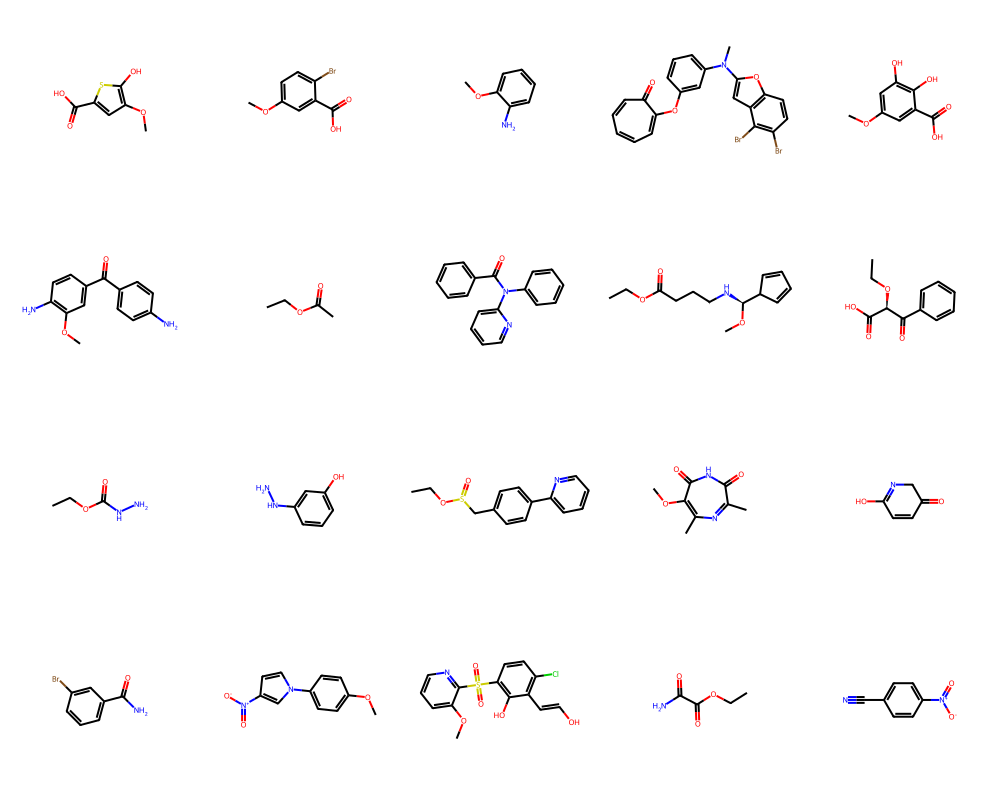

In [13]:
from rdkit.Chem import Draw

valid_mols = [Chem.MolFromSmiles(s) for s in df_all[df_all.valid]["SMILES"]]

Draw.MolsToGridImage(valid_mols[:20], molsPerRow=5)


In [14]:
def tanimoto_similarity(sm1, sm2):
    fp1 = Chem.RDKFingerprint(Chem.MolFromSmiles(sm1))
    fp2 = Chem.RDKFingerprint(Chem.MolFromSmiles(sm2))
    return DataStructs.TanimotoSimilarity(fp1, fp2)


SMILES to SELFIES

In [15]:
pip install selfies


In [16]:
# Cell 1 — Imports
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import QED, Descriptors
import faiss
import random
import selfies as sf

ROOT = Path("..")
DATA = ROOT / "data"
EMB = ROOT / "embeddings"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)


Using: cpu


In [17]:
# Cell 2 — Load FAISS SMILES Index
pubchem_index = faiss.read_index(str(EMB / "pubchem_index.faiss"))
pubchem_meta = pd.read_parquet(EMB / "pubchem_metadata.parquet")

print("PubChem vectors:", pubchem_index.ntotal)


PubChem vectors: 192783


In [18]:
# Cell 3 — SMILES → SELFIES
smiles_list = pubchem_meta["SMILES"].dropna().tolist()

selfies_list = []
for sm in smiles_list:
    try:
        selfies_list.append(sf.encoder(sm))
    except:
        pass

print("Total SELFIES:", len(selfies_list))


Total SELFIES: 193060


In [19]:
# Cell 4 — Vocabulary
alphabet = set()
for s in selfies_list:
    alphabet.update(sf.split_selfies(s))

alphabet = sorted(list(alphabet))
alphabet.append("[EOS]")

token2idx = {t:i for i,t in enumerate(alphabet)}
idx2token = {i:t for t,i in token2idx.items()}
vocab_size = len(alphabet)

print("SELFIES vocab size:", vocab_size)


SELFIES vocab size: 481


In [20]:
# Cell 5 — SELFIES LSTM
class SelfiesLSTM(nn.Module):
    def __init__(self, vocab_size, hidden=256, layers=3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 128)
        self.lstm = nn.LSTM(128, hidden, layers, batch_first=True)
        self.fc = nn.Linear(hidden, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden


model = SelfiesLSTM(vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = nn.CrossEntropyLoss()


In [25]:
# Cell 6
def tensorize_selfies(s):
    tokens = list(sf.split_selfies(s)) + ["[EOS]"]  # ✅ FIX
    return torch.tensor([token2idx[t] for t in tokens], dtype=torch.long)


train_data = selfies_list[:20000]   # 20k is ideal


In [26]:
# Cell 7
def train_epoch():
    model.train()
    total = 0

    for s in train_data:
        x = tensorize_selfies(s)

        inp = x[:-1].unsqueeze(0).to(device)
        tgt = x[1:].to(device)

        optimizer.zero_grad()
        out, _ = model(inp)
        loss = criterion(out.reshape(-1, vocab_size), tgt)
        loss.backward()
        optimizer.step()

        total += loss.item()

    return total / len(train_data)



for epoch in range(5):
    loss = train_epoch()
    print(f"Epoch {epoch+1}, Loss = {loss:.4f}")


Epoch 1, Loss = 1.3381
Epoch 2, Loss = 1.0148
Epoch 3, Loss = 0.9562
Epoch 4, Loss = 0.9241
Epoch 5, Loss = 0.9000


In [40]:
# Cell X — SELFIES generator (NO SEED)

def generate_selfies(max_len=80):
    model.eval()

    # Start token (always valid in SELFIES)
    start_token = "[C]"
    idx = token2idx[start_token]

    x = torch.tensor([[idx]], dtype=torch.long).to(device)
    generated = [start_token]

    hidden = None

    for _ in range(max_len):
        out, hidden = model(x, hidden)
        probs = torch.softmax(out[0, -1], dim=0)

        idx = torch.multinomial(probs, 1).item()
        tok = idx2token[idx]

        if tok == "[EOS]":
            break

        generated.append(tok)
        x = torch.tensor([[idx]], dtype=torch.long).to(device)

    return "".join(generated)


In [41]:
# Cell 9
def decode_and_validate(selfies_strings):
    rows = []
    for s in selfies_strings:
        try:
            sm = sf.decoder(s)
            mol = Chem.MolFromSmiles(sm)
        except:
            mol = None

        if mol:
            rows.append({
                "SMILES": sm,
                "valid": True,
                "MolWt": Descriptors.MolWt(mol),
                "QED": QED.qed(mol),
                "LogP": Descriptors.MolLogP(mol)
            })
        else:
            rows.append({
                "SMILES": None,
                "valid": False,
                "MolWt": None,
                "QED": None,
                "LogP": None
            })

    return pd.DataFrame(rows)


In [42]:
# Cell 10
def pipeline_generate_for_target(target, num_generate=50):
    retrieved = pubchem_meta.sample(3)["SMILES"].tolist()
    retrieved_selfies = [sf.encoder(s) for s in retrieved]

    generated = [
        generate_selfies()
        for _ in range(num_generate)
    ]

    df = decode_and_validate(generated)
    df["target_query"] = target
    return df


targets = [
    "EGFR inhibitor",
    "Serotonin receptor antagonist",
    "Cyclooxygenase-2 inhibitor"
]

df_all = pd.concat(
    [pipeline_generate_for_target(t) for t in targets],
    ignore_index=True
)

df_all


,SMILES,valid,MolWt,QED,LogP,target_query
0,C/C=C/NC(=O)C1=CC=C(C=C1)C,True,175.231,0.733514,2.25842,EGFR inhibitor
1,C1=CC=C(C=C1)C[C@H1](C)[NH3+1],True,136.218,0.624252,0.85950,EGFR inhibitor
2,C(C(=O)[O-1])NC(=O)[C@@H1](C(=O)O)[NH3+1],True,176.128,0.371202,-4.45240,EGFR inhibitor
3,CCSC[NH2+1]C,True,106.214,0.392137,-0.10980,EGFR inhibitor
4,C(C[NH1+1]CCC(=O)[O-1])C(=O)[O-1],True,159.141,0.395743,-4.38440,EGFR inhibitor
...,...,...,...,...,...,...
145,CCC1=NC(=CC(=C1Cl)Cl)Cl,True,210.491,0.645507,3.60420,Cyclooxygenase-2 inhibitor
146,C1O[NH1+1]=C(C=N1)N,True,100.101,0.350354,-2.60230,Cyclooxygenase-2 inhibitor
147,C[NH1+1]CC[NH2+1]C,True,89.162,0.349102,-2.84140,Cyclooxygenase-2 inhibitor
148,C[C@H1]([C@H1](C(=O)O)[NH3+1])CNCCC[NH3+1],True,191.275,0.335356,-2.46080,Cyclooxygenase-2 inhibitor


In [44]:
OUT = DATA / "generated_molecules_selfies_lstm.csv"
df_all.to_csv(OUT, index=False)
print("Saved:", OUT)


Saved: ..\data\generated_molecules_selfies_lstm.csv


In [43]:
df_all.valid.mean()


1.0